In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [77]:
data_path = 'data/final_data.csv'

df = pd.read_csv(data_path)
print(df.shape)
df.head()

(9100, 34)


,Sample_ID,Label,Value_R,Value_C,Magnitude_0,Magnitude_1,Magnitude_2,Magnitude_3,Magnitude_4,Magnitude_5,...,Phase_5,Phase_6,Phase_7,Phase_8,Phase_9,Phase_10,Phase_11,Phase_12,Phase_13,Phase_14
0,1,nothing,0.0,0.0,139435.593,170791.421,176258.484,135388.687,215221.218,196589.843,...,175.297,-163.614,-171.446,-163.435,-158.626,-168.840,-157.760,-161.634,-160.782,-152.673
1,2,nothing,0.0,0.0,1171894.875,163993.812,1542996.750,441958.310,333872.593,700793.187,...,-26.154,18.430,78.518,51.747,9.166,43.648,39.437,20.472,19.448,24.981
2,3,nothing,0.0,0.0,360081.312,183087.625,680353.562,378817.000,374421.812,535006.375,...,-26.310,-110.969,93.626,70.853,-12.300,81.700,14.597,9.510,16.307,-18.706
3,4,nothing,0.0,0.0,331647.343,191307.578,834786.500,354133.187,404361.750,487509.406,...,-23.742,-101.964,79.179,78.230,-16.494,87.193,23.300,4.200,-3.430,-15.823
4,5,nothing,0.0,0.0,207994.593,159652.218,1089567.250,305106.218,486771.343,875787.562,...,-16.320,138.530,-8.710,37.952,175.100,-29.863,-40.171,-44.318,-37.201,78.420


In [78]:
for Label, group in df.groupby('Label'):
    print(f"--- {Label} (n={len(group)}) ---")
    print(group[['Value_R', 'Value_C', 'Magnitude_0', 'Phase_0']].describe().loc[['mean', 'std', 'min', 'max']])
    print()

--- Capacitor (n=600) ---
      Value_R     Value_C   Magnitude_0     Phase_0
mean      0.0   46.666667   6659.450510  -91.218702
std       0.0   30.134183   5541.786938    4.208738
min       0.0   10.000000   1610.688000 -116.218000
max       0.0  100.000000  22004.142000  -77.357000

--- Parallel_RC (n=3600) ---
          Value_R     Value_C  Magnitude_0    Phase_0
mean  2558.333333   46.666667  2066.063585 -30.411078
std   1237.917431   30.113244  1016.150151  19.067477
min    750.000000   10.000000   652.702000 -81.400000
max   4300.000000  100.000000  5062.219000   0.855000

--- Resistor (n=600) ---
          Value_R  Value_C  Magnitude_0    Phase_0
mean  2558.333333      0.0  2601.481760  -0.254850
std   1238.778232      0.0  1269.137951   2.062884
min    750.000000      0.0   686.581000 -13.416000
max   4300.000000      0.0  4971.505000   3.269000

--- Series_RC (n=4200) ---
          Value_R     Value_C   Magnitude_0     Phase_0
mean  2244.285714   46.666667   7104.161770  -66.

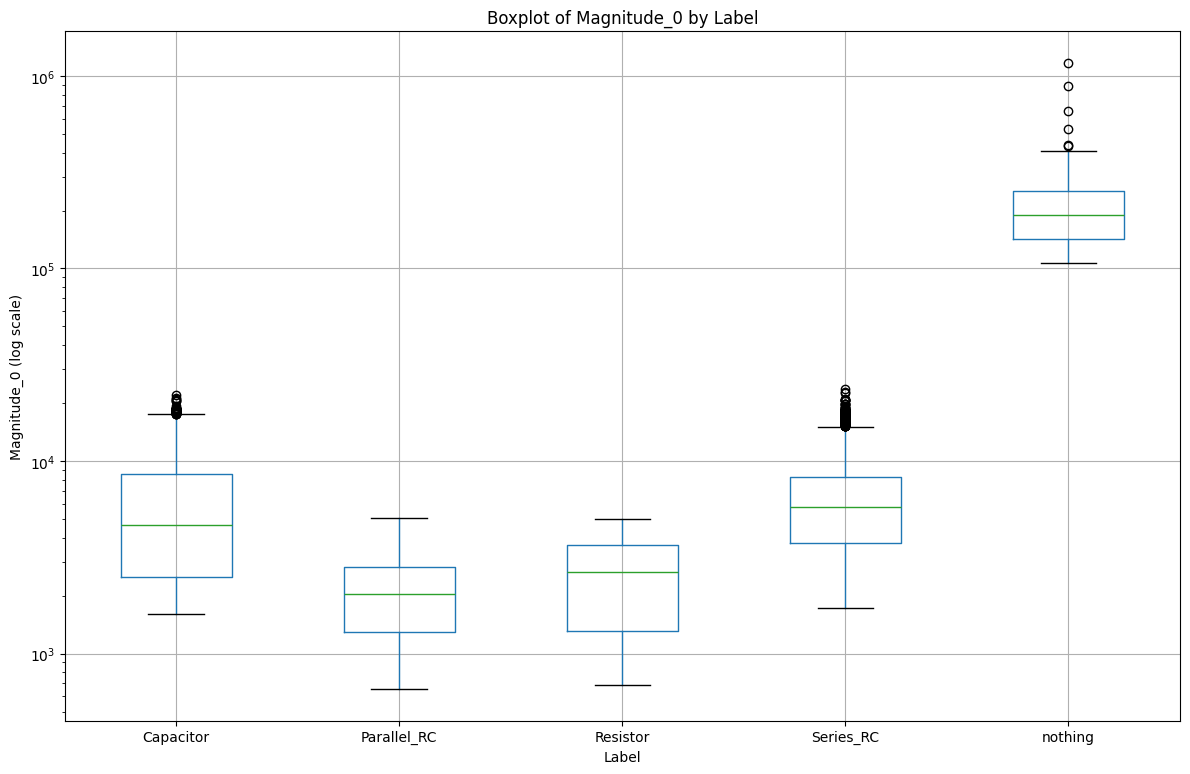

In [79]:
fig, ax = plt.subplots(figsize=(12, 8))
index = 0

df.boxplot(column = f'Magnitude_{index}', by = 'Label', ax = ax)
ax.set_yscale('log')
ax.set_ylabel(f'Magnitude_{index} (log scale)')
plt.suptitle('')
ax.set_title(f'Boxplot of Magnitude_{index} by Label')
plt.tight_layout()
plt.show()

# Isolation Forest

In [80]:
df = pd.read_csv(data_path)
mag_cols = [c for c in df.columns if c.startswith('Magnitude_')]
phase_cols = [c for c in df.columns if c.startswith('Phase_')]
feature_cols = mag_cols + phase_cols

In [81]:
def isolation_forest_outlier(df, mag_cols, phase_cols, group_col=['Label', 'Value_R', 'Value_C'],
                             contamination=0.0, random_state=42, min_group_size=15):
    is_outlier = pd.Series(False, index=df.index)
    for label, group in df.groupby(group_col):
        if len(group) < min_group_size:
            continue  # Skip groups with too few samples

        X = group[mag_cols].apply(lambda col: np.log10(col.clip(lower=1e-6)))
        X = pd.concat([X, group[phase_cols]], axis=1)
        model = IsolationForest(contamination=contamination, random_state=random_state)
        pred = model.fit_predict(X)  # -1 = outlier, 1 = normal
        is_outlier.loc[group.index] = (pred == -1)
    return is_outlier

is_outlier_iforest = isolation_forest_outlier(df, mag_cols, phase_cols, contamination=0.05)
print(f"Outlier detection (Isolation Forest): {is_outlier_iforest.sum()} / {len(df)} "
    f"({is_outlier_iforest.mean()*100:.2f}%)")
print(df.loc[is_outlier_iforest, 'Label'].value_counts())


Outlier detection (Isolation Forest): 455 / 9100 (5.00%)
Label
Series_RC      210
Parallel_RC    180
Capacitor       30
Resistor        30
nothing          5
Name: count, dtype: int64


In [82]:
FINAL_OUTLIER_MASK = is_outlier_iforest  

df_clean = df.loc[~FINAL_OUTLIER_MASK].reset_index(drop=True)
df_removed = df.loc[FINAL_OUTLIER_MASK].reset_index(drop=True)

print(f"Before: {len(df)} rows  ->  After filtering: {len(df_clean)} rows  (removed {len(df_removed)} rows)")
df_clean['Label'].value_counts()

Before: 9100 rows  ->  After filtering: 8645 rows  (removed 455 rows)


Label
Series_RC      3990
Parallel_RC    3420
Capacitor       570
Resistor        570
nothing          95
Name: count, dtype: int64

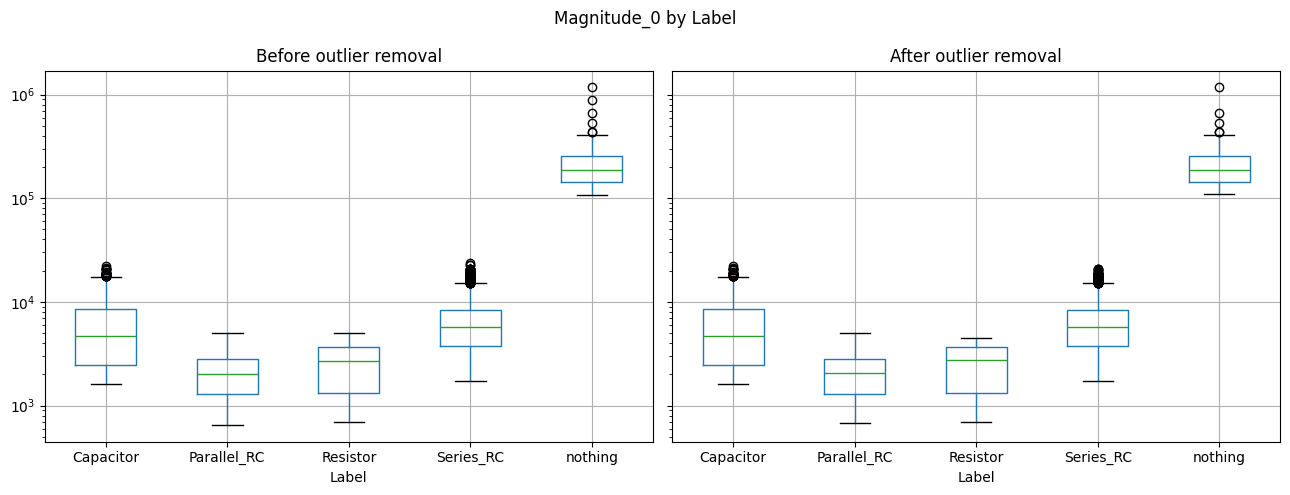

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
df.boxplot(column='Magnitude_0', by='Label', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Before outlier removal')

df_clean.boxplot(column='Magnitude_0', by='Label', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('After outlier removal')

plt.suptitle('Magnitude_0 by Label')
plt.tight_layout()
plt.show()

In [84]:
df_clean.to_csv('final_data_outliers_clean_Iso.csv', index=False)

# IQR (Interquartile Range)

In [85]:
def iqr_outlier_mask(series, k=1.1):
    """Return a boolean mask: True if the value is an outlier according to IQR."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (series < lo) | (series > hi)


def compute_outlier_flags(df, mag_cols, phase_cols, group_cols=('Label', 'Value_R', 'Value_C'),
                           k=1.1, min_group_size=8):
    flags = pd.DataFrame(False, index=df.index, columns=mag_cols + phase_cols)
    for _, g in df.groupby(list(group_cols)):
        if len(g) < min_group_size:
            continue  # qua it mau lap lai de danh gia outlier dang tin cay
        idx = g.index
        for c in mag_cols:
            s = np.log10(g[c].clip(lower=1e-6))
            flags.loc[idx, c] = iqr_outlier_mask(s, k=k).values
        for c in phase_cols:
            flags.loc[idx, c] = iqr_outlier_mask(g[c], k=k).values
    return flags


def monotonic_violation_count(mags, tol_ratio=0.03):
    """
    Dem so lan |Z| tang nguoc bat thuong khi tan so tang (tang > tol_ratio giua 2
    diem lien tiep). Capacitor/Series_RC/Parallel_RC ve ly thuyet |Z| phai giam don
    dieu theo tan so - vi pham dieu nay la dau hieu ro rang cua nhieu do/glitch phan
    cung, va la nguyen nhan chinh gay R2 am sau trong physics extraction (fit dung
    ca 15 diem tan so cung luc nen 1 diem hong cung du pha hong ca fit).
    """
    m = np.asarray(mags, dtype=float)
    up = m[1:] > (1.0 + tol_ratio) * m[:-1]
    return int(up.sum())


def compute_physics_veto(df, mag_cols, physics_labels=('Capacitor', 'Series_RC', 'Parallel_RC'),
                          tol_ratio=0.03, bad_steps=2):
    """
    Veto truc tiep cac dong vi pham rang buoc don dieu, bat ke IQR co bat duoc hay
    khong. Day la lop bao ve quan trong nhat cho physics extraction.
    """
    veto = pd.Series(False, index=df.index)
    mask_label = df['Label'].isin(physics_labels)
    for i in df.index[mask_label]:
        mags = df.loc[i, mag_cols].to_numpy(dtype=float)
        if monotonic_violation_count(mags, tol_ratio=tol_ratio) >= bad_steps:
            veto.loc[i] = True
    return veto


flags = compute_outlier_flags(df, mag_cols, phase_cols, group_cols=('Label', 'Value_R', 'Value_C'), k=1.1)
outlier_count = flags.sum(axis=1)
print("Outlier-count distribution (IQR, per Label+R+C config):")
print(outlier_count.value_counts().sort_index())

physics_veto = compute_physics_veto(df, mag_cols)
print(f"\nRows flagged by physics monotonic veto: {int(physics_veto.sum())} / {len(df)}")

Outlier-count distribution (IQR, per Label+R+C config):
0     6241
1      361
2      111
3       69
4       71
5       53
6       41
7       58
8       56
9       62
10      77
11      74
12      86
13      55
14      60
15      56
16      41
17      29
18      38
19      46
20      50
21      96
22     135
23     156
24     239
25     264
26     215
27     141
28      73
29      39
30       7
Name: count, dtype: int64

Rows flagged by physics monotonic veto: 1388 / 9100


In [86]:
MIN_OUTLIER_COLS = 2

is_outlier_iqr = (outlier_count >= MIN_OUTLIER_COLS) | physics_veto
print(f"Number of rows removed (IQR+Physics veto, threshold={MIN_OUTLIER_COLS}): {is_outlier_iqr.sum()} / {len(df)} "
      f"({is_outlier_iqr.mean()*100:.2f}%)")
print(df.loc[is_outlier_iqr, 'Label'].value_counts())

Number of rows removed (IQR+Physics veto, threshold=2): 2500 / 9100 (27.47%)
Label
Series_RC      1195
Parallel_RC     926
Resistor        209
Capacitor       163
nothing           7
Name: count, dtype: int64


In [87]:
FINAL_OUTLIER_MASK = is_outlier_iqr  

df_clean = df.loc[~FINAL_OUTLIER_MASK].reset_index(drop=True)
df_removed = df.loc[FINAL_OUTLIER_MASK].reset_index(drop=True)

print(f"Before: {len(df)} rows  ->  After filtering: {len(df_clean)} rows  (removed {len(df_removed)} rows)")
df_clean['Label'].value_counts()

Before: 9100 rows  ->  After filtering: 6600 rows  (removed 2500 rows)


Label
Series_RC      3005
Parallel_RC    2674
Capacitor       437
Resistor        391
nothing          93
Name: count, dtype: int64

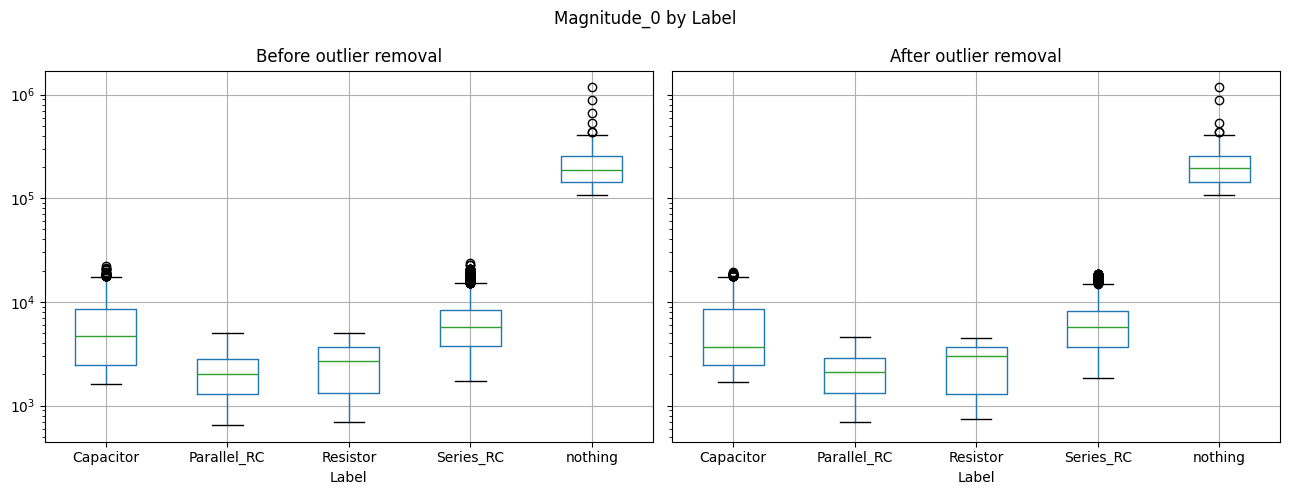

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
df.boxplot(column='Magnitude_0', by='Label', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Before outlier removal')

df_clean.boxplot(column='Magnitude_0', by='Label', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('After outlier removal')

plt.suptitle('Magnitude_0 by Label')
plt.tight_layout()
plt.show()

In [89]:
#I want to export CSV file of removed outliers and clean data of these 2 methods
df_clean.to_csv('final_data_outliers_clean_iqr.csv', index=False)


In [ ]:
import numpy as np

my_array = np.array([[1, 2, 3, 4, 5]]) # sum is 15
print(my_array)

my_array = np.vstack((my_array, my_array)) # sum is 2 * 15
print(my_array)
